***
*Project:* Expressive Piano Generation

*Author:* Jingwei Liu (Ph.D Candidate, Computer Music, UC San Diego)
***

# <span style="background-color:darkorange; color:white; padding:2px 6px">Application & ReadMe</span> 


# Expressive Piano Performance Generation (MIDI Format)

## 1. Audio vs. MIDI

- The music scene is shifted towards audio based composition and production, thus symbolic music generation is marginalized.

- Symbolic music is frequently criticized for its stiffness and non-flexibility in generating listening-based music.

- We argue that, **under the same expressivity of music replay, MIDI as a much more concise representation has advantage over the raw audio format in generation models**.

### Multi-Arguments I/O

Five arguments are extracted from the MIDI files as sufficient statistics for expressive piano performances. The five fields are:

- Note value ($n$): a MIDI note number in range $[21,108]$.
- Time shift ($t$): the onset difference between two subsequent notes in miliseconds, $t = 0$ gives perfectly simultaneous notes.
- Duration ($d$): duration of the note in miliseconds.
- Velocity ($v$): a number in range $[0,127]$, the MIDI default velocity representation.
- Sustain pedal ($p$): the status of the sustain pedal, with binary value on/off (1/0).

In [1]:
import py_midicsv as pm
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import os
import scipy
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
dev = torch.device("cuda") # operate on GPU "cuda" or CPU "cpu"

## 2. Listening-based Data Processing

- *Abandonment of fixed grid.* Use time-shift events and duration measured in miliseconds to generate expressive timing.

- *A homogeneous treatment of monophony and polyphony.* We claim that there is no real simultaneity of notes. For any two notes that are played by a human performer, there is always a time discrepancy between them, no matter how unnoticeable it is. It means that, since there are no simultaneous events, **we can always place the notes in sequential order, by their time onsets.**

- *Not only the notes matter.* **The control events in MIDI may play a crucial role in musical expressivity** (eg. sustain pedal in piano generation). Please listen to "Original.MID" and "no_sustain.mid" for comparison.

- *Mel quantization of auditory features.* Instead of equal division, like the Mel spectrogram, we divide the ranges into uneven chunks to better reflect the perceptual truth. We refer to **Weber’s law** for just noticeable differences as our theoretical foundation for the divisions, where the noticeable difference is proportional to the current value.

<img src="Pictures/division_new.png" style="width:800px">
<caption><center> Figure 1. The categorical distributions for given input features. The divisions obey Weber's law where the perceptual changes are proportional to the values. </center></caption>

In [3]:
# Time Shift Division
division = np.array([2**i for i in range(16)])
division = np.append(0,division)
for j in range(3):
    for i in range(division.size-1):
        comb = division[i+1] + division[i]
        if comb % 2 == 0:
            division = np.append(division, int(comb/2))
    division = np.unique(division)
ts_division = division
ts_division = np.append(ts_division, 35000)
ts_division

array([    0,     1,     2,     3,     4,     5,     6,     7,     8,
           9,    10,    11,    12,    13,    14,    15,    16,    18,
          20,    22,    24,    26,    28,    30,    32,    36,    40,
          44,    48,    52,    56,    60,    64,    72,    80,    88,
          96,   104,   112,   120,   128,   144,   160,   176,   192,
         208,   224,   240,   256,   288,   320,   352,   384,   416,
         448,   480,   512,   576,   640,   704,   768,   832,   896,
         960,  1024,  1152,  1280,  1408,  1536,  1664,  1792,  1920,
        2048,  2304,  2560,  2816,  3072,  3328,  3584,  3840,  4096,
        4608,  5120,  5632,  6144,  6656,  7168,  7680,  8192,  9216,
       10240, 11264, 12288, 13312, 14336, 15360, 16384, 18432, 20480,
       22528, 24576, 26624, 28672, 30720, 32768, 35000])

In [4]:
ts_division[48]

np.int64(256)

In [5]:
# Duration Division
division = np.append([0,20],np.arange(30,90,5))
division = np.append(division, np.arange(90,130,10))
division = np.append(division, np.arange(130,175,15))
division = np.append(division, np.arange(175,275,20))
division = np.append(division, np.arange(275,485,30))
division = np.append(division, np.arange(485,665,45))
division = np.append(division, np.arange(665,1015,70))
division = np.append(division, np.arange(1015,1495,120))
division = np.append(division, np.arange(1495,2095,200))
division = np.append(division, np.arange(2095,2795,350))
division = np.append(division, np.arange(2795,4395,800))
division = np.append(division, np.arange(4395,10395,1000))
division = np.append(division, np.arange(10395,31395,10000))
for i in range(2,60):
    division = np.append(division, int(np.ceil((division[i] + division[i+1])/2)))
division.sort()
dur_division = division
dur_division = np.append(dur_division, 40395)
dur_division

array([    0,    20,    30,    33,    35,    38,    40,    43,    45,
          48,    50,    53,    55,    58,    60,    63,    65,    68,
          70,    73,    75,    78,    80,    83,    85,    88,    90,
          95,   100,   105,   110,   115,   120,   125,   130,   138,
         145,   153,   160,   168,   175,   185,   195,   205,   215,
         225,   235,   245,   255,   265,   275,   290,   305,   320,
         335,   350,   365,   380,   395,   410,   425,   440,   455,
         470,   485,   508,   530,   553,   575,   598,   620,   643,
         665,   700,   735,   770,   805,   840,   875,   910,   945,
         980,  1015,  1075,  1135,  1195,  1255,  1315,  1375,  1435,
        1495,  1595,  1695,  1795,  1895,  1995,  2095,  2270,  2445,
        2620,  2795,  3195,  3595,  3995,  4395,  4895,  5395,  5895,
        6395,  6895,  7395,  7895,  8395,  8895,  9395,  9895, 10395,
       15395, 20395, 30395, 40395])

In [6]:
dur_division[65]

np.int64(508)

In [7]:
# Velocity Change Division
division_vel = np.append(np.arange(-22,-12,2),np.arange(-12,12))
division_vel = np.append(division_vel, np.arange(12,22,2))
division_vel = np.append(np.arange(-34,-22,4), division_vel)
division_vel = np.append(division_vel, np.arange(22,34,4))
division_vel = np.append(np.arange(-94,-34,20), division_vel)
division_vel = np.append(division_vel, np.arange(34,105,20))
vel_division = division_vel
vel_division = np.append(vel_division, 110)
vel_division

array([-94, -74, -54, -34, -30, -26, -22, -20, -18, -16, -14, -12, -11,
       -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  14,  16,  18,
        20,  22,  26,  30,  34,  54,  74,  94, 110])

In [8]:
dur_division = np.append(dur_division, 40395)
vel_division = np.append(vel_division, 110)
ts_division = np.append(ts_division, 35000)

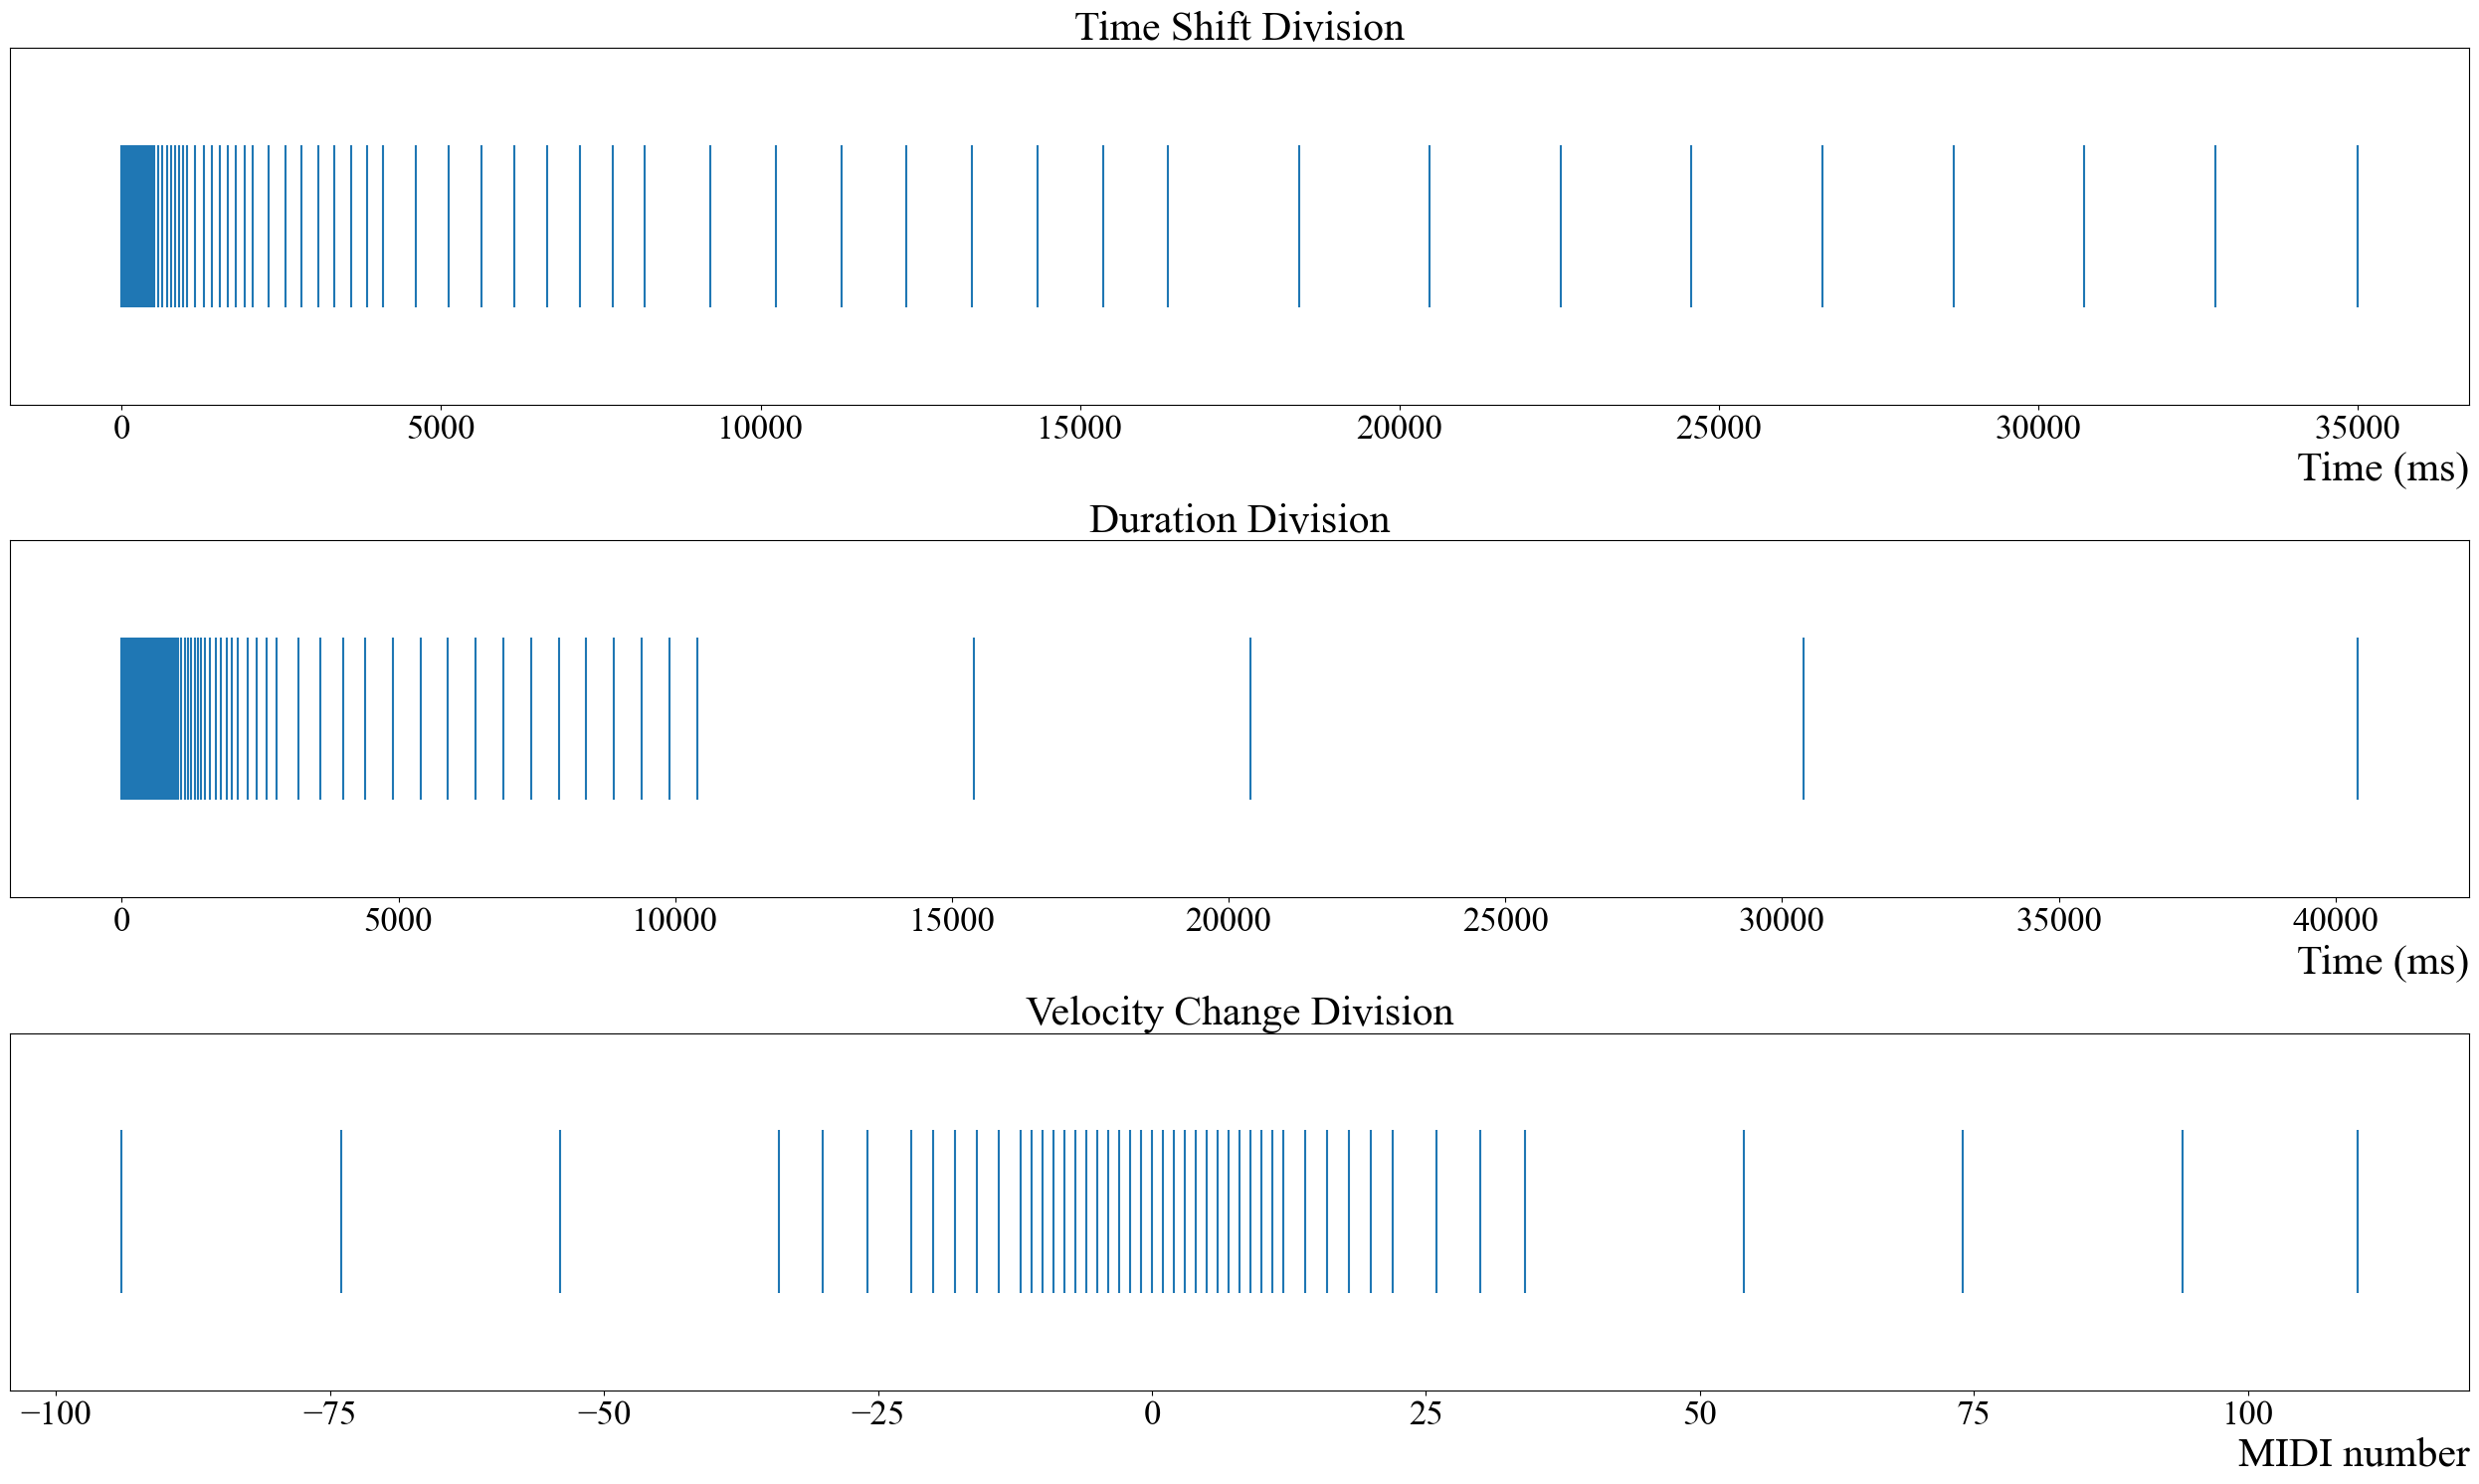

In [9]:
csfont = {'fontname':'Times New Roman'}
matplotlib.rcParams['font.family'] = 'Times New Roman'
plt.rc('xtick', labelsize=25)

fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharey=True, figsize=(25, 15))

ax1.set_title('Duration Division', fontsize=30,**csfont)
ax1.set_xlabel("Time (ms)",horizontalalignment='right',position=(1,25), fontsize=30,**csfont)
ax1.eventplot(dur_division)

ax0.set_title('Time Shift Division', fontsize=30,**csfont)
ax0.set_xlabel("Time (ms)",horizontalalignment='right',position=(1,25), fontsize=30,**csfont)
ax0.eventplot(ts_division)

ax2.set_title('Velocity Change Division', fontsize=30,**csfont)
ax2.set_xlabel("MIDI number",horizontalalignment='right',position=(1,25), fontsize=30,**csfont)
ax2.eventplot(vel_division)
plt.yticks([])

plt.tight_layout(pad=1)
plt.show()

### Categorical Index of Multi-arguments

- $x_n$ -- MIDI note number minus $21$. Original range $[21,108]$, note index range $[0,87]$.

- $x_t$ -- Time shift in miliseconds categorized as Fig.1, index range $[0,104]$.

- $x_d$ -- Duration in miliseconds categorized as Fig.1, index range $[0,119]$.

- $x_v$ -- Velocity difference between two subsequent notes. Categorized as Fig.1, index range $[0,46]$

- $x_p$ -- Sustain pedal status on/off, index range $[0,1]$

## 3. Multi-arguments Sequential Model

The temporal feature of the performance is captured by the sequential model, and the multi-arguments are inherently interdependent. To model their interdependencies, we decompose the temporal predictor into 5 separate LSTMs with inputs conditioned on previous outputs.

<img src="Pictures/LSTM_5.jpg" style="width:800px">
<caption><center> Figure 2. A way to Capture Interdependency among Arguments in a Multi-argument Sequential Model.</center></caption>

The LSTM cell functions as such:

<img src="Pictures/LSTM cell.jpg" style="width:800px">
<caption><center> Figure 3. LSTM cell. A recurrent neural network with forget and update gates that capture longer time dependencies. </center></caption>

In [10]:
def softmax(x):
    if x.ndim == 1:
        e_x = torch.exp(x - torch.max(x))
        p_x = e_x / torch.sum(e_x)
    else:
        e_x = torch.exp(x - torch.max(x,axis=1,keepdims=True)[0])
        p_x = e_x / torch.sum(e_x,axis=1,keepdims=True)
    return p_x

In [11]:
class LSTM(nn.Module):
    def __init__(self, input_len, hidden_size, num_class, num_layers):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.LSTM = nn.LSTM(input_len, hidden_size, num_layers, batch_first = True, device=dev)
        self.output_layer = nn.Linear(hidden_size, num_class, device=dev)
        
    def forward(self, X, hidden_state, cell_state): # input X (batch_size, seq_len, input_len)
#         hidden_state = torch.zeros(self.num_layers, X.size(0), self.hidden_size, device = dev)
#         cell_state = torch.zeros(self.num_layers, X.size(0), self.hidden_size, device = dev)
        out, (hn, cn) = self.LSTM(X,(hidden_state, cell_state))
        out = self.output_layer(out[:,-1,:]) # output (batch_size, seq_len, output_len)
        return out, (hn, cn)

In [12]:
hidden_size = 150
num_layers = 2

input_len1 = 362 # 88+120+47+105+2
num_class1 = 88 # predict note
input_len2 = 362 + 88 
num_class2 = 105 # predict time shift
input_len3 = 362 + 193 
num_class3 = 120 # predict duration
input_len4 = 362 + 313 
num_class4 = 47 # predict velocity change
input_len5 = 362 + 360 
num_class5 = 2 # predict pedal

In [ ]:
model1 = LSTM(input_len1, hidden_size, num_class1, num_layers)
model1.load_state_dict(torch.load("param_400\model1_400", dev, weights_only=True))

model2 = LSTM(input_len2, hidden_size, num_class2, num_layers)
model2.load_state_dict(torch.load("param_400\model2_400", dev, weights_only=True))

model3 = LSTM(input_len3, hidden_size, num_class3, num_layers)
model3.load_state_dict(torch.load("param_400\model3_400", dev, weights_only=True))

model4 = LSTM(input_len4, hidden_size, num_class4, num_layers)
model4.load_state_dict(torch.load("param_400\model4_400", dev, weights_only=True))

model5 = LSTM(input_len5, hidden_size, num_class5, num_layers)
model5.load_state_dict(torch.load("param_400\model5_400", dev, weights_only=True))

<All keys matched successfully>

In [17]:
# model1 = LSTM(input_len1, hidden_size, num_class1, num_layers)
# model1.load_state_dict(torch.load("D:\Jupyter Notebook Files\Expressive Piano\Param_200\model1", dev, weights_only=True))

# model2 = LSTM(input_len2, hidden_size, num_class2, num_layers)
# model2.load_state_dict(torch.load("D:\Jupyter Notebook Files\Expressive Piano\Param_200\model2", dev, weights_only=True))

# model3 = LSTM(input_len3, hidden_size, num_class3, num_layers)
# model3.load_state_dict(torch.load("D:\Jupyter Notebook Files\Expressive Piano\Param_200\model3", dev, weights_only=True))

# model4 = LSTM(input_len4, hidden_size, num_class4, num_layers)
# model4.load_state_dict(torch.load("D:\Jupyter Notebook Files\Expressive Piano\Param_200\model4", dev, weights_only=True))

# model5 = LSTM(input_len5, hidden_size, num_class5, num_layers)
# model5.load_state_dict(torch.load("D:\Jupyter Notebook Files\Expressive Piano\Param_200\model5", dev, weights_only=True))

In [14]:
print(model1.eval())
print(model2.eval())
print(model3.eval())
print(model4.eval())
print(model5.eval())

LSTM(
  (LSTM): LSTM(362, 150, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=150, out_features=88, bias=True)
)
LSTM(
  (LSTM): LSTM(450, 150, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=150, out_features=105, bias=True)
)
LSTM(
  (LSTM): LSTM(555, 150, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=150, out_features=120, bias=True)
)
LSTM(
  (LSTM): LSTM(675, 150, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=150, out_features=47, bias=True)
)
LSTM(
  (LSTM): LSTM(722, 150, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=150, out_features=2, bias=True)
)


### Weight Attentions

In [15]:
model = [model1,model2,model3,model4,model5]
param_att = torch.zeros(5,9)
for i in range(param_att.shape[0]):
    param_att[i,0] = model[i].state_dict()['LSTM.weight_ih_l0'][:,:88].abs().mean() #note
    param_att[i,1] = model[i].state_dict()['LSTM.weight_ih_l0'][:,88:193].abs().mean() #time shift
    param_att[i,2] = model[i].state_dict()['LSTM.weight_ih_l0'][:,193:313].abs().mean() #duration
    param_att[i,3] = model[i].state_dict()['LSTM.weight_ih_l0'][:,313:360].abs().mean() #velocity change
    param_att[i,4] = model[i].state_dict()['LSTM.weight_ih_l0'][:,360:362].abs().mean() #pedal
    
    param_att[i,5] = model[i].state_dict()['LSTM.weight_ih_l0'][:,362:450].abs().mean() #note_next
    param_att[i,6] = model[i].state_dict()['LSTM.weight_ih_l0'][:,450:555].abs().mean() #time shift_next
    param_att[i,7] = model[i].state_dict()['LSTM.weight_ih_l0'][:,555:675].abs().mean() #duration_next
    param_att[i,8] = model[i].state_dict()['LSTM.weight_ih_l0'][:,675:722].abs().mean() #velocity change_next
param_att

tensor([[0.8636, 0.4263, 0.4027, 0.3563, 0.4342,    nan,    nan,    nan,    nan],
        [0.6050, 0.5540, 0.5401, 0.4955, 0.4527, 0.6311,    nan,    nan,    nan],
        [0.5872, 0.4398, 0.6221, 0.5090, 0.4327, 0.6262, 0.5211,    nan,    nan],
        [0.5414, 0.4064, 0.4717, 0.6795, 0.5452, 0.6074, 0.5127, 0.4880,    nan],
        [0.2850, 0.2301, 0.2576, 0.2735, 0.5419, 0.2852, 0.2497, 0.2499, 0.2833]])

In [16]:
model = [model1,model2,model3,model4,model5]
param_att = torch.zeros(5,9)
for i in range(param_att.shape[0]):
    param_att[i,0] = model[i].state_dict()['LSTM.weight_ih_l0'][:,:88].abs().mean() #note
    param_att[i,1] = model[i].state_dict()['LSTM.weight_ih_l0'][:,88:193].abs().mean() #time shift
    param_att[i,2] = model[i].state_dict()['LSTM.weight_ih_l0'][:,193:313].abs().mean() #duration
    param_att[i,3] = model[i].state_dict()['LSTM.weight_ih_l0'][:,313:360].abs().mean() #velocity change
    param_att[i,4] = model[i].state_dict()['LSTM.weight_ih_l0'][:,360:362].abs().mean() #pedal
    
    param_att[i,5] = model[i].state_dict()['LSTM.weight_ih_l0'][:,362:450].abs().mean() #note_next
    param_att[i,6] = model[i].state_dict()['LSTM.weight_ih_l0'][:,450:555].abs().mean() #time shift_next
    param_att[i,7] = model[i].state_dict()['LSTM.weight_ih_l0'][:,555:675].abs().mean() #duration_next
    param_att[i,8] = model[i].state_dict()['LSTM.weight_ih_l0'][:,675:722].abs().mean() #velocity change_next
param_att

tensor([[0.8636, 0.4263, 0.4027, 0.3563, 0.4342,    nan,    nan,    nan,    nan],
        [0.6050, 0.5540, 0.5401, 0.4955, 0.4527, 0.6311,    nan,    nan,    nan],
        [0.5872, 0.4398, 0.6221, 0.5090, 0.4327, 0.6262, 0.5211,    nan,    nan],
        [0.5414, 0.4064, 0.4717, 0.6795, 0.5452, 0.6074, 0.5127, 0.4880,    nan],
        [0.2850, 0.2301, 0.2576, 0.2735, 0.5419, 0.2852, 0.2497, 0.2499, 0.2833]])

In [17]:
param_att[torch.where(param_att.isnan())] = 0
1 - param_att/param_att.max(axis=1)[0].reshape(-1,1) # transparency percent

tensor([[0.0000, 0.5064, 0.5337, 0.5875, 0.4972, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.0412, 0.1221, 0.1441, 0.2149, 0.2827, 0.0000, 1.0000, 1.0000, 1.0000],
        [0.0623, 0.2977, 0.0066, 0.1871, 0.3091, 0.0000, 0.1678, 1.0000, 1.0000],
        [0.2032, 0.4019, 0.3058, 0.0000, 0.1976, 0.1061, 0.2455, 0.2818, 1.0000],
        [0.4741, 0.5754, 0.5246, 0.4953, 0.0000, 0.4738, 0.5392, 0.5389, 0.4772]])

The above matrix shows the attentions of each LSTM model on its input arguments, which can be visualized as below:
 
<img src="Pictures/LSTM_5_weight.jpg" style="width:850px">
<caption><center> Figure 4. Weight Attentions on Input Fields of 5 LSTM models.</center></caption>

- *Observation 1*: Self-attention (attention on the argument of the predictive field) generally weighs more (the blue grid above the red predictive argument).
- *Observation 2*: The 'note' field is informative in predicting all output arguments ($\hat{x}_n$ field weights comparatively higher).
- *Observation 3*: The arguments of the current note weigh more than that of the previous note (the second row has higher weights than the first row).
- *Observation 4*: The time sensitive terms (time shift, duration) rely heavily on the pedal status.

## 4. Generation

In [18]:
gen_num1 = 10  # number of raw generations
gen_num = gen_num1*1
init_index = np.zeros((5,gen_num),dtype=int)

In [19]:
# random initial notes
init_index[0,:] = np.random.randint(88,size=(gen_num))
init_index[1,:] = np.zeros(gen_num)
init_index[2,:] = np.random.randint(100,size=(gen_num,))
init_index[3,:] = np.random.randint(7,size=(gen_num,))+40
init_index[4,:] = np.random.randint(2,size=(gen_num,))

In [22]:
# # specified initial notes
# init_index = np.array([[18,0,22,43,0],
#                       [41,0,31,44,0],
#                       [22,0,21,43,1],
#                       [52,0,73,43,0],
#                       [56,0,16,45,0],
#                       [35,0,29,46,0]])
# init_index = np.repeat(init_index,gen_num1,axis=0).T

In [20]:
gen_len = 500 # number of notes to generate
Generate_index = np.zeros((5,gen_num,gen_len+1),dtype = int)
Generate_index[:,:,0] = init_index
Generate_index = torch.from_numpy(Generate_index).to(dev)
ind = init_index + np.array([0,88,193,313,360]).reshape(5,1)
ind

array([[ 54,  45,  36,   8,  28,  37,  10,  79,  83,  78],
       [ 88,  88,  88,  88,  88,  88,  88,  88,  88,  88],
       [203, 277, 246, 203, 210, 287, 197, 195, 290, 212],
       [354, 353, 355, 357, 358, 353, 358, 355, 355, 357],
       [361, 361, 361, 360, 360, 360, 361, 361, 360, 360]])

In [21]:
input_tensor = torch.zeros(gen_num,1,362*2,device=dev) # input (batch_size, 1, input_len)
for i in range(gen_num):
    input_tensor[i,0,ind[:,i]] = 1

In [22]:
hn1 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
cn1 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
hn2 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
cn2 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
hn3 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
cn3 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
hn4 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
cn4 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
hn5 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)
cn5 = torch.zeros(num_layers, gen_num, hidden_size,device=dev)

In [23]:
for i in range(1,gen_len+1):
    out1, (hn1, cn1) = model1(input_tensor[:,:,:362], hn1, cn1) # input (batch_size, 1, input_len)
    p1 = softmax(out1)
    note_next = torch.multinomial(p1, 1)
    Generate_index[0,:,i:i+1] = note_next
    for j in range(gen_num):
        input_tensor[j,:,362 + note_next[j,0]] = 1
        
    out2, (hn2, cn2) = model2(input_tensor[:,:,:450], hn2, cn2)
    p2 = softmax(out2)
    time_shift_next = torch.multinomial(p2, 1)
    Generate_index[1,:,i:i+1] = time_shift_next
    for j in range(gen_num):
        input_tensor[j,:,450 + time_shift_next[j,0]] = 1
    
    out3, (hn3, cn3) = model3(input_tensor[:,:,:555], hn3, cn3)
    p3 = softmax(out3)
    duration_next = torch.multinomial(p3, 1)
    Generate_index[2,:,i:i+1] = duration_next
    for j in range(gen_num):
        input_tensor[j,:,555 + duration_next[j,0]] = 1
    
    out4, (hn4, cn4) = model4(input_tensor[:,:,:675], hn4, cn4)
    p4 = softmax(out4)
    velocity_next = torch.multinomial(p4, 1)
    Generate_index[3,:,i:i+1] = velocity_next
    for j in range(gen_num):
        input_tensor[j,:,675 + velocity_next[j,0]] = 1
        
    out5, (hn5, cn5) = model5(input_tensor[:,:,:722], hn5, cn5)
    p5 = softmax(out5)
    pedal_next = torch.multinomial(p5, 1)
    Generate_index[4,:,i:i+1] = pedal_next
    for j in range(gen_num):
        input_tensor[j,:,722 + pedal_next[j,0]] = 1
        
    next_tensor = torch.zeros(gen_num,1,362*2,device=dev)
    next_tensor[:,:,:362] = input_tensor[:,:,362:]
    input_tensor = next_tensor

In [51]:
cn5.min()

tensor(-374.9596, device='cuda:0', grad_fn=<MinBackward1>)

In [52]:
cn5.max()

tensor(71.8615, device='cuda:0', grad_fn=<MaxBackward1>)

In [ ]:
for s in range(Generate_index.shape[1]):
    Generate_index_sel = Generate_index[:,s,:].to('cpu').numpy()
    Generation = np.zeros((5,gen_len+1),dtype = int)
    Generation[0,:] = Generate_index_sel[0,:] + 21 # note value
    Generation[4,:] = Generate_index_sel[4,:] # pedal
    vel = 0
    for i in range(gen_len+1):
        Generation[1,i] = np.random.choice(np.arange(ts_division[Generate_index_sel[1,i]],ts_division[Generate_index_sel[1,i]+1]))
        Generation[2,i] = np.random.choice(np.arange(dur_division[Generate_index_sel[2,i]],dur_division[Generate_index_sel[2,i]+1]))
        vel_change = np.random.choice(np.arange(vel_division[Generate_index_sel[3,i]],vel_division[Generate_index_sel[3,i]+1]))
        Generation[3,i] = np.clip(vel + vel_change,30,110)
        vel = Generation[3,i]
    
    # Write to MIDI file
    time = np.cumsum(Generation[1,:])
    MIDI_format = pd.DataFrame(columns=['Time','Type','Note','Velocity'])
    pedal = 0
    for i in range(Generation.shape[1]):
        MIDI_format = pd.concat([MIDI_format, pd.DataFrame([{'Time': time[i],
                             'Type': 'Note_on_c',
                             'Note': Generation[0,i],
                             'Velocity': Generation[3,i]}])], ignore_index=True)
        MIDI_format = pd.concat([MIDI_format, pd.DataFrame([{'Time': (time[i] + Generation[2,i]),
                             'Type': 'Note_off_c',
                             'Note': Generation[0,i],
                             'Velocity': 0}])], ignore_index=True)
        if Generation[4,i] != pedal:
            pedal = Generation[4,i]
            if i == 0:
                MIDI_format = pd.concat([MIDI_format, pd.DataFrame([{'Time': 0,
                                     'Type': 'Control_c',
                                     'Note': 64,
                                     'Velocity': pedal*127}])], ignore_index=True)
            else:
                MIDI_format = pd.concat([MIDI_format, pd.DataFrame([{'Time': np.random.choice(np.arange(time[i-1],time[i]+1)),
                                     'Type': 'Control_c',
                                     'Note': 64,
                                     'Velocity': pedal*127}])], ignore_index=True)
    MIDI_format = MIDI_format.sort_values('Time')
    MIDI_format = MIDI_format.reset_index(drop=True)
    
    generated_csv = open("midi.csv", 'w')
    generated_csv.write("0,0,Header,0,1,480\n")
    generated_csv.write("1,0,Start_track\n")
    generated_csv.write("1,0,Tempo,480000\n")
    generated_csv.write("1,0,Program_c, 0, 0\n")

    for i in range(len(MIDI_format)):
        generated_csv.write("1,"+str(MIDI_format['Time'][i])+","+ MIDI_format['Type'][i] +",0,"+str(MIDI_format['Note'][i])+","+str(MIDI_format['Velocity'][i])+"\n")

    end_time = MIDI_format['Time'][i] + 480
    generated_csv.write("1," + str(end_time) +", End_track\n")
    generated_csv.write("0, 0, End_of_file")
    generated_csv.close()
    
    # Parse the CSV output of the previous command back into a MIDI file
    midi_object = pm.csv_to_midi("midi.csv")

    # Save the parsed MIDI file to disk
    with open("Generation\generated_[("+ str(s) + ")].mid", "wb") as output_file:
    # with open("generated_note_55_61_42_0_0_zero.mid", "wb") as output_file:
        midi_writer = pm.FileWriter(output_file)
        midi_writer.write(midi_object)